In [33]:
from pathlib import Path
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# Для отображения числе не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [5]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
marketplace = pd.read_csv(data_path)
marketplace.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [6]:
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       25335 non-null  object 
 1   platform_num  25335 non-null  int64  
 2   first_login   25335 non-null  object 
 3   reg_dt        25331 non-null  object 
 4   browser       25335 non-null  object 
 5   first_buy     24361 non-null  object 
 6   target        25335 non-null  float64
 7   total_buy     25335 non-null  float64
 8   total_return  25335 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [7]:
marketplace.describe()

,platform_num,target,total_buy,total_return
count,25335.00,25335.00,25335.00,25335.00
mean,6.47,0.00,898.55,334.08
std,17.02,0.25,6815.55,2882.91
min,1.00,-3.43,0.00,0.00
25%,2.00,0.00,19.36,0.00
50%,3.00,0.00,52.72,0.00
75%,6.00,0.00,203.53,0.00
max,674.00,0.30,490447.99,207893.84


## Количество отрицательных значений **target**

In [8]:
marketplace[marketplace["target"] < 0]["target"].count()

np.int64(353)

In [9]:
marketplace[marketplace["target"] > 0]["target"].count()

np.int64(1966)

In [10]:
marketplace["target"].describe()

count   25335.00
mean        0.00
std         0.25
min        -3.43
25%         0.00
50%         0.00
75%         0.00
max         0.30
Name: target, dtype: float64

<Axes: >

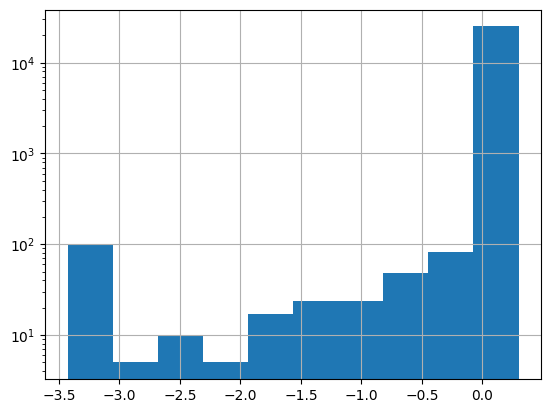

In [11]:
marketplace["target"].hist(log=True)

# Изучение дат

In [12]:
marketplace["first_login"] = pd.to_datetime(marketplace["first_login"])
marketplace["reg_dt"] = pd.to_datetime(marketplace["reg_dt"])
marketplace["first_buy"] = pd.to_datetime(marketplace["first_buy"])
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


In [13]:
marketplace[
    (marketplace["first_login"] < marketplace["reg_dt"]) | # первый логин раньше регистрации
    (marketplace["first_buy"] < marketplace["first_login"]) | # первая покупка раньше певого логина
    (marketplace["first_buy"] < marketplace["reg_dt"]) # первая покупка раньше регистрации
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 16777 entries, 1 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       16777 non-null  object        
 1   platform_num  16777 non-null  int64         
 2   first_login   16777 non-null  datetime64[ns]
 3   reg_dt        16777 non-null  datetime64[ns]
 4   browser       16777 non-null  object        
 5   first_buy     16640 non-null  datetime64[ns]
 6   target        16777 non-null  float64       
 7   total_buy     16777 non-null  float64       
 8   total_return  16777 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.3+ MB


# Добавление новых признаков датасету для анализа
1. **age_days** - количество дней с первой покупки пользователя
2. **age_group** - разбиение пользователей по группам на основе количества дней с первой покупки
3. **only_returns** - флаг, говорящий о том, что у пользователя нет покупок, только возвраты

In [14]:
today = marketplace["first_buy"].max()
marketplace["age_days"] = (today - marketplace["first_buy"]).dt.days
marketplace["age_days"].describe()

count   24361.00
mean      135.43
std        86.01
min         0.00
25%        85.00
50%       122.00
75%       165.00
max       717.00
Name: age_days, dtype: float64

In [15]:
bins = [0, 85, 122, 165, 717, float("inf")]
labels = ["new", "young", "mid", "mature", "old"]

marketplace["age_group"] = pd.cut(
    marketplace["age_days"],
    bins=bins,
    labels=labels,
    right=False
)
marketplace["age_group"] = marketplace["age_group"].cat.add_categories("inactive")
marketplace.loc[marketplace["first_buy"].isna(), "age_group"] = "inactive"
marketplace["age_group"].describe()

count     25335
unique        6
top         mid
freq       6247
Name: age_group, dtype: object

In [16]:
marketplace["only_returns"] = (marketplace["total_buy"] == 0) & (marketplace["total_return"] > 0)
marketplace["only_returns"].describe()

count     25335
unique        2
top       False
freq      25183
Name: only_returns, dtype: object

# Анализ пользователей у которых есть возрвраты

In [17]:
df_with_returns = pd.DataFrame(marketplace[marketplace["total_return"] != 0 ])
df_with_returns.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days
count,5402.00,5402,5402,5215,5402.00,5402.00,5402.00,5215.00
mean,12.31,2025-02-15 01:55:41.429100544,2024-09-17 14:53:48.137726720,2025-02-01 22:44:53.614573312,-0.02,3438.65,1566.82,173.05
min,1.00,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-08-08 00:00:00,-3.43,0.00,20.00,5.00
25%,2.00,2024-12-22 00:00:00,2024-05-30 06:00:00,2024-12-18 00:00:00,0.00,76.82,75.00,114.00
50%,5.00,2025-03-13 00:00:00,2024-12-07 00:00:00,2025-03-12 00:00:00,0.00,373.38,229.06,135.00
75%,9.00,2025-03-30 00:00:00,2025-03-07 00:00:00,2025-04-02 00:00:00,0.00,1803.39,893.30,219.00
max,674.00,2025-07-21 00:00:00,2025-07-24 00:00:00,2025-07-20 00:00:00,0.30,490447.99,207893.84,717.00
std,32.06,NaN,NaN,NaN,0.42,14330.97,6087.10,106.56


In [18]:
df_with_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5402 entries, 2 to 25334
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5402 non-null   object        
 1   platform_num  5402 non-null   int64         
 2   first_login   5402 non-null   datetime64[ns]
 3   reg_dt        5402 non-null   datetime64[ns]
 4   browser       5402 non-null   object        
 5   first_buy     5215 non-null   datetime64[ns]
 6   target        5402 non-null   float64       
 7   total_buy     5402 non-null   float64       
 8   total_return  5402 non-null   float64       
 9   age_days      5215 non-null   float64       
 10  age_group     5402 non-null   category      
 11  only_returns  5402 non-null   bool          
dtypes: bool(1), category(1), datetime64[ns](3), float64(4), int64(1), object(2)
memory usage: 475.0+ KB


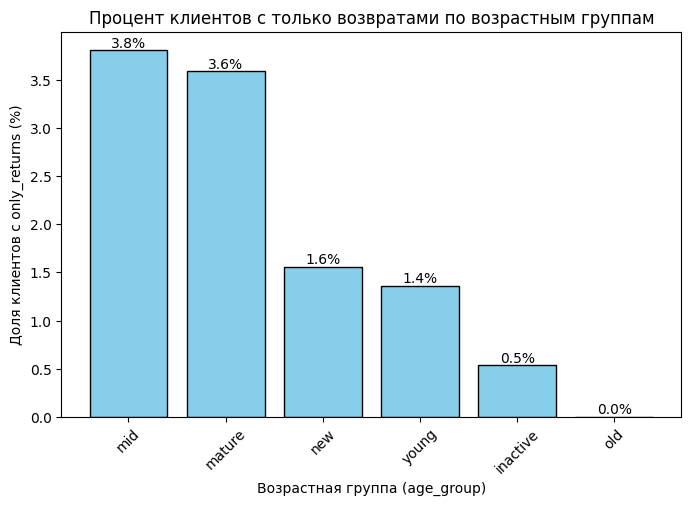

In [19]:
returns_by_browser = df_with_returns.groupby("age_group", observed=True)[
    "only_returns"].mean() * 100

returns_by_browser = returns_by_browser.sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_browser.index,
              returns_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Возрастная группа (age_group)")
ax.set_title("Процент клиентов с только возвратами по возрастным группам")
plt.xticks(rotation=45)
plt.show()

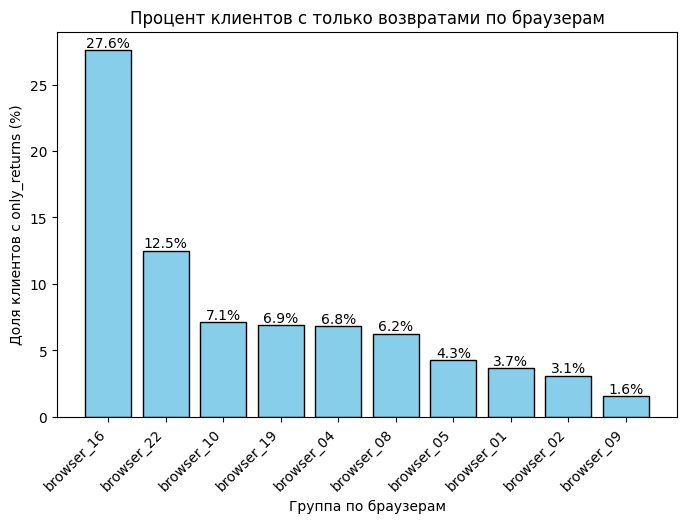

In [20]:
returns_by_browser = df_with_returns.groupby("browser")[
    "only_returns"].mean() * 100

returns_by_browser = returns_by_browser.sort_values(
    ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_browser.index,
              returns_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Группа по браузерам")
ax.set_title("Процент клиентов с только возвратами по браузерам")
plt.xticks(rotation=45, ha='right')
plt.show()

## Изучение признака platform_num

In [21]:
df_with_returns[df_with_returns["platform_num"] == df_with_returns["platform_num"].max()]

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False


In [22]:
df_with_returns.sort_values("platform_num", ascending=False).head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False
14553,user_014550,647,2024-10-02,2024-09-05,browser_03,2024-09-21,-0.00,15754.61,10643.36,307.00,mature,False
3067,user_003065,542,2024-10-11,2024-07-26,browser_02,2024-09-15,0.10,66582.73,20983.01,313.00,mature,False
18597,user_018594,540,2024-12-14,2024-12-01,browser_03,2024-11-26,0.30,18992.27,10651.05,241.00,mature,False
17874,user_017871,475,2024-11-02,2024-10-31,browser_03,2024-12-09,0.22,20179.29,4050.00,228.00,mature,False
10881,user_010878,399,2025-03-30,2024-01-27,browser_03,2025-03-16,0.30,5364.42,2498.61,131.00,mid,False
7787,user_007784,391,2024-12-05,2024-12-09,browser_06,2024-12-15,-2.03,3425.46,2120.53,222.00,mature,False
435,user_000433,358,2024-10-02,2024-10-03,browser_03,2024-09-29,0.00,5073.51,3175.00,299.00,mature,False
12776,user_012773,352,2025-03-22,2022-12-28,browser_03,2025-03-16,0.00,9723.93,9682.00,131.00,mid,False
18049,user_018046,349,2024-09-26,2024-01-11,browser_09,2024-01-21,0.00,55602.37,19282.62,551.00,mature,False


Топ-10 по количеству устройств выглядит неестественным.
### Список гипотез:
- Гипотеза А: технический баг:\
Количество устройств считается неправильно
- Гипотеза B: мошеннические аккаунты
- Гипотеза C: коллективные аккаунты

#### Отличительные признаки
Топ-10 по количеству устройств выше 75-го перцентиля по total_buy и total_return.

In [23]:
df_with_large_platform_num = pd.DataFrame(
    df_with_returns[df_with_returns["platform_num"] > df_with_returns["platform_num"].quantile(0.9)]
)
df_with_large_platform_num.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days
count,520.00,520,520,519,520.00,520.00,520.00,519.00
mean,74.02,2025-01-05 15:52:36.923076864,2024-09-20 08:54:27.692307712,2024-12-20 15:12:49.942196480,-0.00,7962.68,3405.91,216.37
min,25.00,2024-09-21 00:00:00,2022-10-19 00:00:00,2023-12-31 00:00:00,-3.43,0.00,21.71,10.00
25%,32.00,2024-10-24 00:00:00,2024-07-24 12:00:00,2024-10-15 12:00:00,0.00,376.82,161.50,127.00
50%,46.00,2024-12-29 12:00:00,2024-11-01 00:00:00,2025-01-08 00:00:00,0.00,1456.56,638.17,198.00
75%,78.25,2025-03-17 00:00:00,2025-02-01 06:00:00,2025-03-20 00:00:00,0.30,6127.29,2550.00,282.50
max,674.00,2025-07-19 00:00:00,2025-07-19 00:00:00,2025-07-15 00:00:00,0.30,490447.99,207893.84,572.00
std,79.10,NaN,NaN,NaN,0.48,27389.97,11128.94,112.30


# Проверка гипотезы о большом ***platform_num***
Сравним распределение категориального признака ***browser*** между двумя независимыми группами:
1. Пользователи с ***platform_num*** > 90-го перцентиля
2. Все остальные

Используем критерий χ², чтобы оценить насколько сильно отличаются частоты категорий.\
H<sub>0</sub>: Распределение браузеров одинаково в обеих группах\
H<sub>1</sub>: Распределение браузеров отличается\
Уровень значимости α = 0.05

Если принимаем гипотезу H<sub>1</sub> - есть аномальные каналы связи по которым приходят боты.

In [39]:
marketplace["browser"] = marketplace["browser"].astype("category")

threshold = marketplace["platform_num"].quantile(0.9)

df_large = marketplace[marketplace["platform_num"] > threshold]
df_small = marketplace[marketplace["platform_num"] <= threshold]
contingency = pd.crosstab(
    marketplace["browser"],
    marketplace["platform_num"] > threshold
)
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p:.3g}")

p-value: 1.22e-58


***p_value*** < 0.05:
- H<sub>0</sub> отвергается
- распределения браузеров отличаются статистически значимо
- есть браузеры, которые непропорционально часто встречаются в "подозрительной" группе
- возможен фродовый канал трафика

## Анализ остатков
residual ~ N(0,1)\
~95% попадают в [-2;2]

In [ ]:
residuals = (contingency - expected) / expected**0.5
suspicious = residuals[True][residuals[True] > 2].sort_values(ascending=False)
display(suspicious)

browser
browser_03   13.28
browser_28    2.91
browser_30    2.91
browser_17    2.59
Name: True, dtype: float64

Браузеры:
* 03
* 28
* 30
* 17

Встречаются чаще у пользователей с большим количеством устройств

# Черновик
## TO DO LIST:
* Оценить как долго кастомер у нас уже покупает (на основе этого можно построить признаки return_per_date, buy_per_date)
* Оценить долю only_returns, средние total_buy и total_return в группе пользователей с подозрительными браузерами